In [1]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

In [5]:
# ================= НАСТРОЙКИ =================
MODEL_PATH = '../models/best_yolo26s.pt'
DATA_YAML = '../dataset/data.yaml'
TARGET_CLASS_NAME = 'Wine_Botle'
IOU_THRESHOLD = 0.5
# =============================================

In [7]:
# 1. Загрузка модели и данных
print("Загрузка модели и данных...")
model = YOLO(MODEL_PATH)

with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data = yaml.safe_load(f)

# Определяем индекс целевого класса
if isinstance(TARGET_CLASS_NAME, int):
    target_class_idx = TARGET_CLASS_NAME
else:
    target_class_idx = data['names'].index(TARGET_CLASS_NAME)
    
class_name = data['names'][target_class_idx]
print(f"Целевой класс: '{class_name}' (индекс {target_class_idx})")

Загрузка модели и данных...
Целевой класс: 'Wine_Botle' (индекс 0)


In [9]:
# 2. Подготовка путей к валидационной выборке
val_dir = Path(data['val'])
if isinstance(val_dir, list):
    val_dir = Path(val_dir[0])

# Предполагаем стандартную структуру YOLO: val/images и val/labels
images_dir = val_dir / 'images'
labels_dir = val_dir / 'labels'

# Fallback: если папки images нет, возможно, val_dir уже указывает на изображения
if not images_dir.exists():
    images_dir = val_dir
    labels_dir = val_dir.parent / 'labels'

In [11]:
img_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
print(f"Найдено изображений для валидации: {len(img_files)}")


Найдено изображений для валидации: 45


In [13]:
# 3. Сбор предсказаний и Ground Truth
print("Сбор данных с валидационной выборки (это может занять время)...")
dataset_data = []

for img_path in img_files:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]
    
    # --- Чтение Ground Truth ---
    label_path = labels_dir / (img_path.stem + '.txt')
    gts = []
    if label_path.exists():
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(parts[0])
                if cls == target_class_idx:
                    xc, yc, wn, hn = map(float, parts[1:5])
                    # Перевод из нормализованных координат YOLO в абсолютные пиксели
                    x1 = (xc - wn/2) * w
                    y1 = (yc - hn/2) * h
                    x2 = (xc + wn/2) * w
                    y2 = (yc + hn/2) * h
                    gts.append([x1, y1, x2, y2])
    
    # --- Получение предсказаний модели ---
    # Используем conf=0.001, чтобы модель вернула абсолютно все кандидаты
    results = model.predict(source=str(img_path), conf=0.001, verbose=False, save=False)
    preds = []
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()
        classes = results[0].boxes.cls.cpu().numpy()
        
        for box, conf, cls in zip(boxes, confs, classes):
            if int(cls) == target_class_idx:
                preds.append([box[0], box[1], box[2], box[3], conf])
                
    dataset_data.append({
        'gts': np.array(gts) if len(gts) > 0 else np.empty((0, 4)),
        'preds': np.array(preds) if len(preds) > 0 else np.empty((0, 5))
    })


Сбор данных с валидационной выборки (это может занять время)...


In [15]:
# 4. Функция расчёта метрик для заданного порога уверенности
def calculate_metrics(threshold, data, iou_thresh=0.5):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives
    
    for item in data:
        gts = item['gts']
        preds = item['preds']
        
        # Фильтруем предсказания по текущему порогу уверенности
        valid_preds = preds[preds[:, 4] >= threshold]
        
        # Массив для отслеживания уже сопоставленных объектов GT
        matched_gt = np.zeros(len(gts), dtype=bool)
        
        # Сортируем предсказания по уверенности (от высокой к низкой) для жадного сопоставления
        sorted_indices = np.argsort(valid_preds[:, 4])[::-1]
        valid_preds = valid_preds[sorted_indices]
        
        for pred in valid_preds:
            pred_box = pred[:4]
            
            if len(gts) == 0:
                fp += 1
                continue
            
            # Вычисляем IoU между предсказанием и всеми GT-боксами
            xx1 = np.maximum(gts[:, 0], pred_box[0])
            yy1 = np.maximum(gts[:, 1], pred_box[1])
            xx2 = np.minimum(gts[:, 2], pred_box[2])
            yy2 = np.minimum(gts[:, 3], pred_box[3])
            
            inter_w = np.maximum(0, xx2 - xx1)
            inter_h = np.maximum(0, yy2 - yy1)
            inter_area = inter_w * inter_h
            
            pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
            gt_areas = (gts[:, 2] - gts[:, 0]) * (gts[:, 3] - gts[:, 1])
            
            union_area = pred_area + gt_areas - inter_area
            ious = inter_area / np.maximum(union_area, 1e-6)
            
            # Находим GT с максимальным IoU
            best_iou_idx = np.argmax(ious)
            best_iou = ious[best_iou_idx]
            
            if best_iou >= iou_thresh and not matched_gt[best_iou_idx]:
                tp += 1
                matched_gt[best_iou_idx] = True
            else:
                fp += 1
                
        # Несопоставленные GT считаются пропущенными (FN)
        fn += np.sum(~matched_gt)
        
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, f1

In [17]:
# 5. Поиск оптимального порога
print("Расчёт метрик для различных порогов...")
thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []
f1_scores = []


Расчёт метрик для различных порогов...


In [19]:
for t in thresholds:
    p, r, f1 = calculate_metrics(t, dataset_data, IOU_THRESHOLD)
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# Находим порог с максимальным F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]

print("\n" + "="*60)
print(f"🎯 ОПТИМАЛЬНЫЙ ПОРОГ УВЕРЕННОСТИ: {best_threshold:.2f}")
print(f"   Максимальный F1-score:       {best_f1:.4f}")
print(f"   Precision при этом пороге:   {best_precision:.4f}")
print(f"   Recall при этом пороге:      {best_recall:.4f}")
print("="*60 + "\n")



🎯 ОПТИМАЛЬНЫЙ ПОРОГ УВЕРЕННОСТИ: 0.35
   Максимальный F1-score:       0.8783
   Precision при этом пороге:   0.8523
   Recall при этом пороге:      0.9058



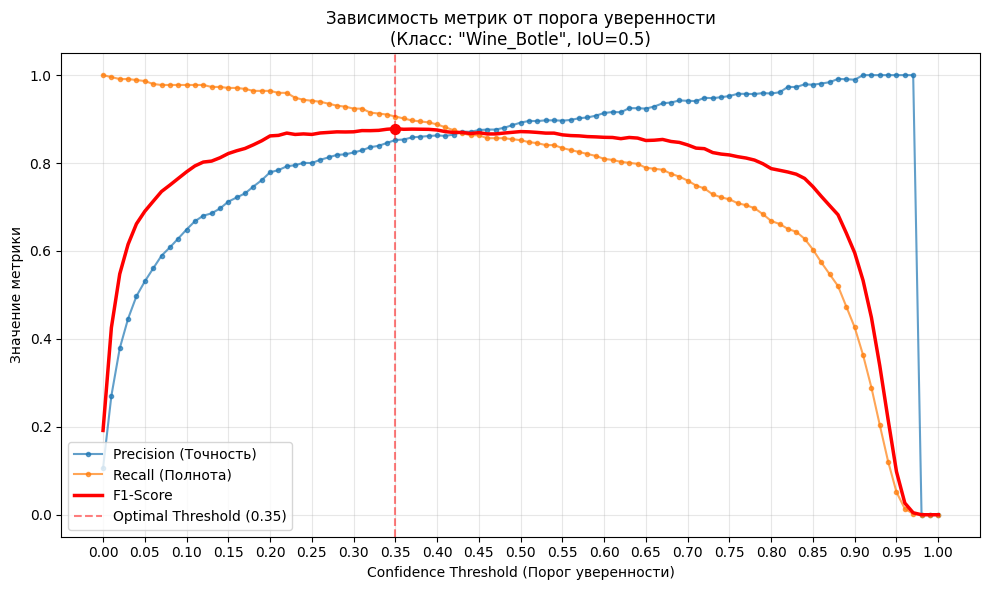

In [21]:
# 6. Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision (Точность)', marker='.', alpha=0.7)
plt.plot(thresholds, recalls, label='Recall (Полнота)', marker='.', alpha=0.7)
plt.plot(thresholds, f1_scores, label='F1-Score', linewidth=2.5, color='red')

# Отмечаем оптимальную точку на графике
plt.axvline(best_threshold, color='red', linestyle='--', alpha=0.5, label=f'Optimal Threshold ({best_threshold:.2f})')
plt.scatter([best_threshold], [best_f1], color='red', zorder=5, s=50)

plt.title(f'Зависимость метрик от порога уверенности\n(Класс: "{class_name}", IoU={IOU_THRESHOLD})')
plt.xlabel('Confidence Threshold (Порог уверенности)')
plt.ylabel('Значение метрики')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 1.05, 0.05))
plt.tight_layout()
plt.show()